# Energy Model Calibration (DESNZ vs ABM)

Self-contained calibration: load ABM outputs, load DESNZ LSOA elec+gas, compare per-dwelling (ABM per UPRN) to DESNZ per-meter, and plot distributions by year.


In [20]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# display options
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)


## Paths and settings
Edit these as needed. `RUN_MODEL` defaults to False (use existing outputs).

In [ ]:
# Data paths (relative to repo root)
GEOJSON     = Path('../data/epc_abm_newcastle.geojson')
CLIMATE     = Path('../data/ncc_2t_timeseries_2010_2039.parquet')
HIDP_CSV    = Path('../data/hidp_uprn_matches_tiered.csv')
ELEC_XLSX   = Path('../data/LSOA_domestic_elec_2010-2023.xlsx')
GAS_XLSX    = Path('../data/LSOA_domestic_gas_2010-2023.xlsx')
OUTDIR      = Path('results/calibration')
OUTDIR.mkdir(parents=True, exist_ok=True)

# Calibrated override from serl_calibration_clean.ipynb.
# Auto-pick the newest results/calibration_*/calibrated_config.yaml (same
# convention as the paper2/sensitivity notebooks) so this tracks the latest
# calibration without manual edits. As of 2026-06-04 this resolves to the v4
# config, which carries the fuel-specific electric base heating slope
# (heating_slope_kWh_per_deg_electric) that fixes the all-electric LSOA
# over-ramp. To pin a specific config, set CALIBRATED_CONFIG explicitly instead.
_cal_dirs = sorted(Path('../results').glob('calibration_*'), key=lambda p: p.name)
_cal_dirs = [d for d in _cal_dirs if (d / 'calibrated_config.yaml').exists()]
if not _cal_dirs:
    raise FileNotFoundError('No calibration_*/calibrated_config.yaml under ../results')
CALIBRATED_CONFIG = _cal_dirs[-1] / 'calibrated_config.yaml'
print(f'Using calibrated config: {CALIBRATED_CONFIG}')

# Model outputs (produced separately via run.py)
MODEL_PARQUET = OUTDIR / 'model_timeseries.parquet'
AGENT_PARQUET = OUTDIR / 'agent_timeseries.parquet'

RUN_MODEL = False           # set True to rerun long model here (slow)
YEARS = [2021, 2022, 2023]  # align with SERL multi-year validation window
START_UTC = f'{min(YEARS)}-01-01T00:00:00Z'
END_UTC   = f'{max(YEARS) + 1}-01-01T00:00:00Z'  # exclusive
LSOA_COL = 'lsoa_code'

## Load GeoJSON + HIDP enrichment (coalesce duplicate area codes)

In [22]:
gdf = gpd.read_file(GEOJSON)
print(f"Loaded {len(gdf):,} dwellings from {GEOJSON}")

# ensure UPRN
if 'UPRN' not in gdf.columns:
    for alt in ['uprn','fid']:
        if alt in gdf.columns:
            gdf['UPRN'] = gdf[alt]
            break
assert 'UPRN' in gdf.columns, 'No UPRN field found.'
gdf['UPRN'] = gdf['UPRN'].astype(str).str.strip()

# HIDP merge (optional)
if HIDP_CSV.exists():
    hidp_df = pd.read_csv(HIDP_CSV, low_memory=False)
    hidp_df.columns = [c.strip() for c in hidp_df.columns]
    hidp_df['uprn_chr'] = hidp_df['uprn_chr'].astype(str).str.strip()
    hidp_df = hidp_df.drop_duplicates('uprn_chr')
    before = len(gdf)
    gdf = gdf.merge(hidp_df, how='left', left_on='UPRN', right_on='uprn_chr', suffixes=('_geo','_hidp'))
    print(f"Merged HIDP: {before:,} -> {len(gdf):,}; unmatched: {gdf['uprn_chr'].isna().sum():,}")
    # coalesce lsoa if duplicated
    if 'lsoa_code_geo' in gdf.columns or 'lsoa_code_hidp' in gdf.columns:
        gdf['lsoa_code'] = gdf.get('lsoa_code_geo').combine_first(gdf.get('lsoa_code_hidp'))
        gdf.drop(columns=[c for c in ['lsoa_code_geo','lsoa_code_hidp'] if c in gdf.columns], inplace=True)
else:
    print('Skipping HIDP enrichment (file not found)')

assert LSOA_COL in gdf.columns, f"{LSOA_COL} not found after merge"


Loaded 97,714 dwellings from ../data/epc_abm_newcastle.geojson
Merged HIDP: 97,714 -> 97,714; unmatched: 440


## Optional: run model (slow) or load existing outputs
If `RUN_MODEL=False`, ensure `model_timeseries.parquet` and `agent_timeseries.parquet` exist in OUTDIR.


## Optional: run per-LSOA batch (ABM → annual per-dwelling)

In [23]:
# Toggle to run per-LSOA batch simulations (writes to results_lsoa)
RUN_LSOA_BATCH = True
LSOA_BATCH_CODES = None  # e.g., ['E01035614', 'E01008358']; None = all LSOAs in GEOJSON
LSOA_BATCH_OUTDIR = Path('results_lsoa')
LSOA_BATCH_MAX_PROCS = 5
END_UTC = '2025-01-01T00:00:00Z'  # batch end time (exclusive)


In [24]:
# Convenience: pick the largest LSOAs by dwelling count for quick tests
if 'FILTER_TOP20_LSOA' not in globals():
    FILTER_TOP20_LSOA = False
# Default False for production-aligned multi-year calibration runs.
FILTER_TOP20_LSOA = False
if FILTER_TOP20_LSOA:
    lsoa_counts = gdf.groupby(LSOA_COL)['UPRN'].nunique().sort_values(ascending=False)
    LSOA_BATCH_CODES = list(lsoa_counts.head(50).index)
    print(f"Selected top {len(LSOA_BATCH_CODES)} LSOAs by dwellings: {LSOA_BATCH_CODES[:5]}...")


In [25]:
import hashlib
import multiprocessing as mp
from household_energy.run_lsoa_batch import RunConfig, _run_single_lsoa


def _sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def run_lsoa_batch(lsoas=None, max_procs=LSOA_BATCH_MAX_PROCS):
    stamp = pd.Timestamp.utcnow().strftime('%Y%m%d')
    cfg = RunConfig(
        geojson=GEOJSON,
        climate=CLIMATE,
        hidp_csv=HIDP_CSV if HIDP_CSV.exists() else None,
        config_path=CALIBRATED_CONFIG.resolve(),
        start_utc=START_UTC,
        end_utc=END_UTC,
        days=None,
        local_tz='Europe/London',
        lsoa_col=LSOA_COL,
        outdir=LSOA_BATCH_OUTDIR,
        agent_collect_every=1,
        save_model_timeseries=False,
        stamp=stamp,
    )
    cfg_hash = _sha256(cfg.config_path)

    gdf_all = gpd.read_file(GEOJSON)
    all_lsoas = sorted(gdf_all[LSOA_COL].astype(str).unique())
    target_lsoas = list(lsoas) if lsoas is not None else list(all_lsoas)
    total = len(target_lsoas)
    print(f"Running {total} LSOAs -> {cfg.outdir} (stamp {stamp})")
    print(f"Using calibrated config: {cfg.config_path}")
    print(f"Config sha256: {cfg_hash}")
    print(f"Window: [{cfg.start_utc}, {cfg.end_utc})")
    cfg.outdir.mkdir(parents=True, exist_ok=True)

    tasks = [(lsoa, cfg, i + 1, total) for i, lsoa in enumerate(target_lsoas)]
    if max_procs == 1:
        rows = [_run_single_lsoa(*task) for task in tasks]
    else:
        try:
            with mp.Pool(processes=max(1, max_procs)) as pool:
                rows = pool.starmap(_run_single_lsoa, tasks)
        except RuntimeError as e:
            print(f"Pool failed ({e}); falling back to serial.")
            rows = [_run_single_lsoa(*task) for task in tasks]

    annual_all = pd.concat([r for r in rows if r is not None], ignore_index=True)
    if not annual_all.empty:
        annual_all['config_path'] = str(cfg.config_path)
        annual_all['config_sha256'] = cfg_hash
        annual_all['run_start_utc'] = cfg.start_utc
        annual_all['run_end_utc'] = cfg.end_utc
        stamp_path = cfg.outdir / f"abm_year_all_{cfg.stamp}.parquet"
        annual_all.to_parquet(stamp_path, index=False)
        annual_all.to_csv(cfg.outdir / f"abm_year_all_{cfg.stamp}.csv", index=False)
        print(f"Saved combined annual table -> {stamp_path.name}")
    return annual_all

if RUN_LSOA_BATCH:
    abm_year_batch = run_lsoa_batch(LSOA_BATCH_CODES, max_procs=LSOA_BATCH_MAX_PROCS)
    display(abm_year_batch.head())


Running 185 LSOAs -> results_lsoa (stamp 20260601)
Using calibrated config: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260522_092130/calibrated_config.yaml
Config sha256: a4552218ecea13c15489b6ca67261e8a10a462344f88bd8e27c0374b3264e722
Window: [2021-01-01T00:00:00Z, 2025-01-01T00:00:00Z)
[41/185] LSOA E01008331 – loading dwellings…
[11/185] LSOA E01008298 – loading dwellings…
[1/185] LSOA E01008288 – loading dwellings…
[21/185] LSOA E01008311 – loading dwellings…
[31/185] LSOA E01008321 – loading dwellings…
    step 3,506/35,064 ( 10%) for E01008288
    step 3,506/35,064 ( 10%) for E01008321
    step 3,506/35,064 ( 10%) for E01008331
    step 3,506/35,064 ( 10%) for E01008298
    step 3,506/35,064 ( 10%) for E01008311
    step 7,012/35,064 ( 20%) for E01008288
    step 7,012/35,064 ( 20%) for E01008321
    step 7,012/35,064 ( 20%) for E01008331
    step 7,012/35,064 ( 20%) for E01008298
    step 10,518/35,064 ( 30%) for E01008288
    step 7,012/35,064 ( 20%) for E0

,abm_kwh,abm_elec_kwh,abm_gas_kwh,abm_other_kwh,year,lsoa_code,run_dwellings,run_gas_dwellings,run_gas_dwellings_strict,run_off_gas_dwellings,run_unknown_gas_connection_dwellings,run_gas_heated_dwellings,run_electric_heated_dwellings,run_other_heated_dwellings,run_electric_dwellings,run_other_dwellings,abm_kwh_per_dw,abm_elec_kwh_per_dw,abm_gas_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_heated_dw,abm_other_kwh_per_dw,config_path,config_sha256,run_start_utc,run_end_utc
0,7.821733e+06,1.293142e+06,6.528592e+06,0.0,2021,E01008288,428,396,394,32,2,395,32,0,428,0,18275.077309,3021.358765,15253.718545,16486.342265,16528.079841,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z
1,8.060012e+06,1.297149e+06,6.762863e+06,0.0,2022,E01008288,428,396,394,32,2,395,32,0,428,0,18831.803780,3030.721362,15801.082418,17077.937563,17121.172848,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z
2,7.941345e+06,1.294487e+06,6.646857e+06,0.0,2023,E01008288,428,396,394,32,2,395,32,0,428,0,18554.543464,3024.502672,15530.040792,16784.993583,16827.487238,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z
3,7.995318e+06,1.299712e+06,6.695606e+06,0.0,2024,E01008288,428,396,394,32,2,395,32,0,428,0,18680.650463,3036.711267,15643.939196,16908.095899,16950.901205,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z
4,8.099711e+06,1.414304e+06,6.685407e+06,0.0,2021,E01008289,415,393,337,22,56,393,22,0,415,0,19517.375678,3407.960718,16109.414960,17011.214271,17011.214271,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z


## Load DESNZ LSOA data (elec + gas)

In [26]:
import re

NORM_COLMAP = {
    "Local authority code": "la_code",
    "Local authority": "local_authority",
    "MSOA code": "msoa_code",
    "Middle layer super output area": "msoa_name",
    "LSOA code": "lsoa_code",
    "Lower layer super output area": "lsoa_name",
    "Number of meters": "meters",
    "Total consumption (kWh)": "total_kwh",
    "Mean consumption (kWh per meter)": "mean_kwh",
    "Median consumption (kWh per meter)": "median_kwh",
}

def tidy_lsoa(xlsx_path: Path, fuel: str) -> pd.DataFrame:
    book = pd.read_excel(xlsx_path, sheet_name=None, header=4, engine='openpyxl')
    # drop first sheet (notes)
    first = next(iter(book))
    book.pop(first, None)
    frames = []
    for sheet_name, df in book.items():
        df = df.copy()
        df.columns = df.columns.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        df = df.rename(columns={k: v for k, v in NORM_COLMAP.items() if k in df.columns})
        wanted = ["lsoa_code","lsoa_name","meters","total_kwh"]
        keep = [c for c in wanted if c in df.columns]
        if not keep:
            continue
        df = df[keep].copy()
        for c in {"meters","total_kwh"} & set(keep):
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','',regex=False), errors='coerce')
        m = re.search(r"(20\d{2})", str(sheet_name))
        if not m:
            continue
        df["year"] = int(m.group(1))
        df["fuel"] = fuel
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["year","fuel","lsoa_code","meters","total_kwh"])
    out = pd.concat(frames, ignore_index=True)
    out = out[out["year"].isin(YEARS)]
    return out[["year","fuel","lsoa_code","meters","total_kwh"]]

desnz_elec = tidy_lsoa(ELEC_XLSX, "elec")
desnz_gas  = tidy_lsoa(GAS_XLSX,  "gas")
print(f"DESNZ elec rows: {len(desnz_elec):,}; gas rows: {len(desnz_gas):,}")


DESNZ elec rows: 127,947; gas rows: 127,947


## DESNZ per-LSOA per-year (elec+gas / elec meters)

In [27]:
# DESNZ: build per-fuel and combined per-meter metrics at LSOA-year level
# Combined denominator uses electricity meters (common dwelling proxy).

desz_e = (
    desnz_elec.groupby([LSOA_COL, 'year'], as_index=False)
    .agg(elec_kwh=('total_kwh', 'sum'), elec_meters=('meters', 'sum'))
)
desz_g = (
    desnz_gas.groupby([LSOA_COL, 'year'], as_index=False)
    .agg(gas_kwh=('total_kwh', 'sum'), gas_meters=('meters', 'sum'))
)

desz = desz_e.merge(desz_g, on=[LSOA_COL, 'year'], how='outer')
for c in ['elec_kwh', 'elec_meters', 'gas_kwh', 'gas_meters']:
    desz[c] = pd.to_numeric(desz[c], errors='coerce')

desz['elec_kwh_per_dw'] = desz['elec_kwh'] / desz['elec_meters']
desz['gas_kwh_per_gas_dw'] = desz['gas_kwh'] / desz['gas_meters']
desz['desnz_kwh'] = desz['elec_kwh'].fillna(0.0) + desz['gas_kwh'].fillna(0.0)
desz['desnz_kwh_per_dw'] = desz['desnz_kwh'] / desz['elec_meters']

desnz_tot = desz.copy()


## ABM batch results (per-LSOA runs)

In [28]:
from pathlib import Path

# Load latest ABM batch rollup from the selected batch output directory.
# Accept both .parquet and .csv (the v4 elec-slope batch wrote csv); pick newest by mtime.
batch_outdir = globals().get('LSOA_BATCH_OUTDIR', Path('results_lsoa'))
rollups = sorted(
    list(Path(batch_outdir).glob('abm_year_all_*.parquet')) +
    list(Path(batch_outdir).glob('abm_year_all_*.csv')),
    key=lambda p: p.stat().st_mtime,
)
if not rollups:
    raise FileNotFoundError(f'No abm_year_all_<stamp>.(parquet|csv) in {batch_outdir}')
abm_path = rollups[-1]
abm_batch = pd.read_parquet(abm_path) if abm_path.suffix == '.parquet' else pd.read_csv(abm_path)
if 'run_dwellings' not in abm_batch.columns:
    abm_batch['run_dwellings'] = abm_batch['abm_kwh'] / abm_batch['abm_kwh_per_dw']
print(f"Loaded ABM batch: {abm_path.name} ({len(abm_batch):,} rows)")


Loaded ABM batch: abm_year_all_20260601.parquet (740 rows)


## Combine and analyze

In [29]:
# Combine ABM batch with DESNZ and summarize
cmp = abm_batch.merge(desnz_tot, on=[LSOA_COL, 'year'], how='inner')
cmp = cmp[cmp['year'].isin(YEARS)].copy()

# Core alignment ratios
cmp['ratio_total'] = cmp['abm_kwh_per_dw'] / cmp['desnz_kwh_per_dw']
cmp['ratio_elec'] = cmp['abm_elec_kwh_per_dw'] / cmp['elec_kwh_per_dw']

# Gas ratio: assumed vs strict denominator choices (diagnostic split)
cmp['ratio_gas_assumed'] = cmp['abm_gas_kwh_per_gas_dw'] / cmp['gas_kwh_per_gas_dw']
cmp['abm_gas_kwh_per_gas_dw_strict'] = cmp['abm_gas_kwh'] / cmp['run_gas_dwellings_strict'].replace({0: np.nan})
cmp['ratio_gas_strict'] = cmp['abm_gas_kwh_per_gas_dw_strict'] / cmp['gas_kwh_per_gas_dw']

# Back-compat aliases for downstream cells
cmp['ratio_gas'] = cmp['ratio_gas_assumed']
cmp['ratio'] = cmp['ratio_total']

# Denominator uncertainty flags
cmp['unknown_share'] = cmp['run_unknown_gas_connection_dwellings'] / cmp['run_dwellings'].replace({0: np.nan})
UNKNOWN_SHARE_CUTOFF = 0.15
cmp['gas_denominator_quality'] = np.where(cmp['unknown_share'] <= UNKNOWN_SHARE_CUTOFF, 'low-uncertainty', 'high-uncertainty')

print(f"Rows: {len(cmp):,} across {cmp[LSOA_COL].nunique()} LSOAs")
print(cmp['gas_denominator_quality'].value_counts(dropna=False).to_string())

# Summary helpers
def _mape(r):
    r = pd.to_numeric(r, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return (r.sub(1.0).abs().mean() * 100.0) if len(r) else np.nan


def _summary_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for yr, sub in df.groupby('year'):
        rows.append({
            'scope': label,
            'year': yr,
            'n': len(sub),
            'mape_total_pct': _mape(sub['ratio_total']),
            'mape_elec_pct': _mape(sub['ratio_elec']),
            'mape_gas_assumed_pct': _mape(sub['ratio_gas_assumed']),
            'mape_gas_strict_pct': _mape(sub['ratio_gas_strict']),
            'median_ratio_total': sub['ratio_total'].median(),
            'median_ratio_elec': sub['ratio_elec'].median(),
            'median_ratio_gas_assumed': sub['ratio_gas_assumed'].median(),
            'median_ratio_gas_strict': sub['ratio_gas_strict'].median(),
        })
    return pd.DataFrame(rows).sort_values(['scope', 'year'])

# Two headline views: all LSOAs vs low-uncertainty only
summary_all = _summary_table(cmp, 'all_lsoas')
summary_low_uncert = _summary_table(cmp[cmp['unknown_share'] <= UNKNOWN_SHARE_CUTOFF], 'low_uncert_lsoas')
headline_summary = pd.concat([summary_all, summary_low_uncert], ignore_index=True)
display(headline_summary.round(3).style.set_caption('Headline alignment summary: all vs low-uncertainty LSOAs'))

# Uncertainty bucket diagnostics
cmp['unknown_bucket'] = pd.cut(
    cmp['unknown_share'],
    bins=[-np.inf, 0.05, 0.20, np.inf],
    labels=['<5%', '5-20%', '>20%'],
)

bucket_summary = (
    cmp.groupby(['year', 'unknown_bucket'], observed=False)
       .agg(
           n=('ratio_total', 'size'),
           median_ratio_total=('ratio_total', 'median'),
           median_ratio_elec=('ratio_elec', 'median'),
           median_ratio_gas_assumed=('ratio_gas_assumed', 'median'),
           median_ratio_gas_strict=('ratio_gas_strict', 'median'),
           mape_total_pct=('ratio_total', _mape),
           mape_elec_pct=('ratio_elec', _mape),
           mape_gas_assumed_pct=('ratio_gas_assumed', _mape),
           mape_gas_strict_pct=('ratio_gas_strict', _mape),
       )
       .reset_index()
)
display(bucket_summary.round(3).style.set_caption('Uncertainty-bucket diagnostics'))

# Correlation matrix across LSOA-year rows (alignment structure)
score_cols = [
    'abm_kwh_per_dw', 'desnz_kwh_per_dw',
    'abm_elec_kwh_per_dw', 'elec_kwh_per_dw',
    'abm_gas_kwh_per_gas_dw', 'abm_gas_kwh_per_gas_dw_strict', 'gas_kwh_per_gas_dw',
]
score_df = cmp[score_cols].replace([np.inf, -np.inf], np.nan).dropna()
correlation_matrix = score_df.corr(method='pearson')
display(correlation_matrix.round(3).style.set_caption('Pearson correlation matrix (LSOA-year)'))

# Single-number closeness score (1.0 is perfect)
def _closeness_from_mape(mape_pct):
    if pd.isna(mape_pct):
        return np.nan
    return max(0.0, 1.0 - (mape_pct / 100.0))

corr_total = score_df['abm_kwh_per_dw'].corr(score_df['desnz_kwh_per_dw']) if len(score_df) else np.nan
corr_elec = score_df['abm_elec_kwh_per_dw'].corr(score_df['elec_kwh_per_dw']) if len(score_df) else np.nan
corr_gas = score_df['abm_gas_kwh_per_gas_dw'].corr(score_df['gas_kwh_per_gas_dw']) if len(score_df) else np.nan

mape_total = _mape(cmp['ratio_total'])
mape_elec = _mape(cmp['ratio_elec'])
mape_gas = _mape(cmp['ratio_gas_assumed'])

closeness_components = {
    'level_total': _closeness_from_mape(mape_total),
    'level_elec': _closeness_from_mape(mape_elec),
    'level_gas_assumed': _closeness_from_mape(mape_gas),
    'shape_total_corr': corr_total,
    'shape_elec_corr': corr_elec,
    'shape_gas_corr': corr_gas,
}
closeness_score = float(np.nanmean(list(closeness_components.values())))

print('Closeness components:')
for k, v in closeness_components.items():
    print(f'  {k:20s} = {v:.3f}' if pd.notna(v) else f'  {k:20s} = NaN')
print(f'Composite closeness score (0-1): {closeness_score:.3f}')



Rows: 555 across 185 LSOAs
gas_denominator_quality
low-uncertainty     426
high-uncertainty    129


,scope,year,n,mape_total_pct,mape_elec_pct,mape_gas_assumed_pct,mape_gas_strict_pct,median_ratio_total,median_ratio_elec,median_ratio_gas_assumed,median_ratio_gas_strict
0,all_lsoas,2021,185,28.942000,13.971000,33.107000,161.897000,1.278000,1.116000,1.297000,1.391000
1,all_lsoas,2022,185,49.443000,20.089000,56.424000,212.614000,1.493000,1.202000,1.576000,1.684000
2,all_lsoas,2023,185,43.569000,18.283000,49.731000,200.615000,1.419000,1.188000,1.488000,1.608000
3,low_uncert_lsoas,2021,142,25.282000,14.087000,28.028000,32.890000,1.243000,1.113000,1.280000,1.345000
4,low_uncert_lsoas,2022,142,45.227000,19.894000,50.910000,57.115000,1.454000,1.202000,1.537000,1.618000
5,low_uncert_lsoas,2023,142,39.102000,18.175000,44.031000,49.935000,1.396000,1.184000,1.460000,1.526000


,year,unknown_bucket,n,median_ratio_total,median_ratio_elec,median_ratio_gas_assumed,median_ratio_gas_strict,mape_total_pct,mape_elec_pct,mape_gas_assumed_pct,mape_gas_strict_pct
0,2021,<5%,99,1.242000,1.099000,1.271000,1.285000,26.059000,12.862000,28.046000,29.257000
1,2021,5-20%,55,1.251000,1.150000,1.294000,1.435000,24.424000,16.267000,30.348000,44.176000
2,2021,>20%,31,1.421000,1.111000,1.554000,2.543000,46.167000,13.440000,54.163000,837.965000
3,2022,<5%,99,1.456000,1.186000,1.498000,1.540000,46.118000,19.017000,50.981000,52.645000
4,2022,5-20%,55,1.461000,1.224000,1.572000,1.696000,43.510000,21.534000,52.459000,70.651000
5,2022,>20%,31,1.714000,1.199000,1.881000,3.109000,70.588000,20.916000,80.840000,1027.953000
6,2023,<5%,99,1.401000,1.181000,1.456000,1.458000,39.992000,17.850000,44.326000,45.910000
7,2023,5-20%,55,1.396000,1.196000,1.488000,1.650000,37.740000,19.073000,45.695000,62.882000
8,2023,>20%,31,1.691000,1.193000,1.794000,2.977000,65.333000,18.262000,74.153000,989.966000


,abm_kwh_per_dw,desnz_kwh_per_dw,abm_elec_kwh_per_dw,elec_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_dw_strict,gas_kwh_per_gas_dw
abm_kwh_per_dw,1.000000,0.805000,0.305000,0.162000,0.957000,0.159000,0.577000
desnz_kwh_per_dw,0.805000,1.000000,0.311000,0.418000,0.759000,0.046000,0.863000
abm_elec_kwh_per_dw,0.305000,0.311000,1.000000,0.726000,0.374000,-0.052000,0.518000
elec_kwh_per_dw,0.162000,0.418000,0.726000,1.000000,0.253000,-0.016000,0.716000
abm_gas_kwh_per_gas_dw,0.957000,0.759000,0.374000,0.253000,1.000000,0.145000,0.615000
abm_gas_kwh_per_gas_dw_strict,0.159000,0.046000,-0.052000,-0.016000,0.145000,1.000000,0.010000
gas_kwh_per_gas_dw,0.577000,0.863000,0.518000,0.716000,0.615000,0.010000,1.000000


Closeness components:
  level_total          = 0.593
  level_elec           = 0.826
  level_gas_assumed    = 0.536
  shape_total_corr     = 0.805
  shape_elec_corr      = 0.726
  shape_gas_corr       = 0.615
Composite closeness score (0-1): 0.683


In [30]:
cmp_2023 = cmp[cmp["year"] == 2023].copy()
print(f"2023 rows: {len(cmp_2023):,} across {cmp_2023[LSOA_COL].nunique()} LSOAs")
display(cmp_2023.head())


2023 rows: 185 across 185 LSOAs


,abm_kwh,abm_elec_kwh,abm_gas_kwh,abm_other_kwh,year,lsoa_code,run_dwellings,run_gas_dwellings,run_gas_dwellings_strict,run_off_gas_dwellings,run_unknown_gas_connection_dwellings,run_gas_heated_dwellings,run_electric_heated_dwellings,run_other_heated_dwellings,run_electric_dwellings,run_other_dwellings,abm_kwh_per_dw,abm_elec_kwh_per_dw,abm_gas_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_heated_dw,abm_other_kwh_per_dw,config_path,config_sha256,run_start_utc,run_end_utc,elec_kwh,elec_meters,gas_kwh,gas_meters,elec_kwh_per_dw,gas_kwh_per_gas_dw,desnz_kwh,desnz_kwh_per_dw,ratio_total,ratio_elec,ratio_gas_assumed,abm_gas_kwh_per_gas_dw_strict,ratio_gas_strict,ratio_gas,ratio,unknown_share,gas_denominator_quality,unknown_bucket
2,7.941345e+06,1.294487e+06,6.646857e+06,0.0,2023,E01008288,428,396,394,32,2,395,32,0,428,0,18554.543464,3024.502672,15530.040792,16784.993583,16827.487238,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1828980.060,676.0,7.126411e+06,622.0,2705.591805,11457.252002,8.955391e+06,13247.619535,1.400595,1.117871,1.465010,16870.196596,1.472447,1.465010,1.400595,0.004673,low-uncertainty,<5%
5,8.224623e+06,1.416200e+06,6.808423e+06,0.0,2023,E01008289,415,393,337,22,56,393,22,0,415,0,19818.368967,3412.529941,16405.839026,17324.232051,17324.232051,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1845525.965,657.0,7.253760e+06,646.0,2809.019734,11228.730018,9.099286e+06,13849.749706,1.430955,1.214847,1.542849,20203.036190,1.799227,1.542849,1.430955,0.134940,low-uncertainty,5-20%
8,9.983329e+06,2.128547e+06,7.854782e+06,0.0,2023,E01008290,613,518,363,95,155,399,90,124,613,0,16286.018057,3472.344272,12813.673785,15163.671873,19686.170501,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,2264402.646,758.0,6.209958e+06,527.0,2987.338583,11783.601639,8.474361e+06,11179.895396,1.456724,1.162354,1.286845,21638.517989,1.836325,1.286845,1.456724,0.252855,high-uncertainty,>20%
11,1.333707e+07,2.641054e+06,1.069602e+07,0.0,2023,E01008291,941,885,795,56,90,883,58,0,941,0,14173.298933,2806.645941,11366.652992,12085.898831,12113.273460,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,2363358.401,1032.0,9.623457e+06,993.0,2290.075970,9691.296563,1.198682e+07,11615.131675,1.220244,1.225569,1.247088,13454.113793,1.388268,1.247088,1.220244,0.095643,low-uncertainty,5-20%
14,8.335417e+06,1.132639e+06,7.202778e+06,0.0,2023,E01008292,311,307,306,4,1,306,5,0,311,0,26801.983568,3641.925779,23160.057790,23461.817500,23538.490106,0.0,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1531834.853,549.0,7.485609e+06,541.0,2790.227419,13836.615087,9.017444e+06,16425.216056,1.631758,1.305243,1.695633,23538.490106,1.701174,1.695633,1.631758,0.003215,low-uncertainty,<5%


In [31]:
# Diagnose high-discrepancy LSOAs (ballooning archetypes)
THRESH_RATIO = 1.5
cmp_hi = cmp_2023[cmp_2023['ratio'] >= THRESH_RATIO].copy()
print(f"High-ratio rows (ratio >= {THRESH_RATIO}): {len(cmp_hi):,} across {cmp_hi[LSOA_COL].nunique()} LSOAs")

# Merge back to ABM batch to get dwellings and property info
hi_with_abm = cmp_hi.merge(abm_batch, on=[LSOA_COL, 'year', 'abm_kwh_per_dw', 'abm_kwh', 'run_dwellings'], suffixes=('', '_abm'))

# Archetype contribution within high-ratio set
def archetype_contrib(df):
    return (
        df.groupby('property_type')['abm_kwh']
          .sum()
          .sort_values(ascending=False)
          .to_frame(name='abm_kwh')
    )

# If property_type not present, skip
if 'property_type' in hi_with_abm.columns:
    pt = archetype_contrib(hi_with_abm)
    display(pt.head(10))

# Top LSOAs by ratio with per-dwelling stats
cols = [LSOA_COL, 'year', 'abm_kwh_per_dw', 'desnz_kwh_per_dw', 'ratio', 'run_dwellings', 'elec_meters']
display(cmp_hi.sort_values('ratio', ascending=False).head(20)[cols])

# Spread of ratios and kWh per dwelling
print('Quantiles (ratio):')
print(cmp['ratio'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print('Quantiles (ABM kWh/dw):')
print(cmp['abm_kwh_per_dw'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))


High-ratio rows (ratio >= 1.5): 68 across 68 LSOAs


,lsoa_code,year,abm_kwh_per_dw,desnz_kwh_per_dw,ratio,run_dwellings,elec_meters
50,E01008305,2023,12650.158043,4118.546787,3.071510,764,1007.0
551,E01035622,2023,10164.427493,3527.754520,2.881274,497,568.0
554,E01035623,2023,11859.245092,4956.080365,2.392868,477,613.0
488,E01008577,2023,29280.257435,13014.345787,2.249845,155,1107.0
506,E01033547,2023,17395.901333,8496.573756,2.047402,1194,1426.0
527,E01035614,2023,27784.343929,14390.178241,1.930785,1394,1335.0
533,E01035616,2023,22740.059507,11853.289233,1.918460,616,640.0
56,E01008307,2023,23889.007758,12512.387164,1.909229,814,930.0
530,E01035615,2023,24417.580273,12887.776347,1.894631,603,593.0
62,E01008311,2023,30276.796183,16627.436225,1.820894,640,881.0


Quantiles (ratio):
0.50    1.371564
0.75    1.550420
0.90    1.689680
0.95    1.809041
0.99    2.525208
Name: ratio, dtype: float64
Quantiles (ABM kWh/dw):
0.50    18831.803780
0.75    23426.047473
0.90    27976.291333
0.95    30665.083454
0.99    34890.995580
Name: abm_kwh_per_dw, dtype: float64


In [32]:
# LSOAs with big ABM/DESNZ gaps
RATIO_THRESH = 1.5
hi_lsoas = cmp.loc[cmp["ratio"] >= RATIO_THRESH, LSOA_COL].unique()
print(f"{len(hi_lsoas)} high-ratio LSOAs (ratio ≥ {RATIO_THRESH})")

# Pull features from the geo data
feat_cols = [
    LSOA_COL, "UPRN", "property_type", "sap_rating", "floor_area_m2",
    "property_age", "main_fuel_type", "main_heating_system",
    "retrofit_envelope_score", "is_off_gas", "is_electric_heating",
    "is_gas", "is_oil", "is_solid_fuel"
]
feat_df = gdf[gdf[LSOA_COL].isin(hi_lsoas)][[c for c in feat_cols if c in gdf.columns]].copy()

print("\nTop property types by count (high-ratio LSOAs):")
display(feat_df["property_type"].value_counts().head(10))

print("\nSAP summary:")
display(feat_df["sap_rating"].describe())

print("\nFuel / off-gas counts:")
for col in ["is_off_gas", "is_electric_heating", "is_gas", "is_oil", "is_solid_fuel"]:
    if col in feat_df:
        display(feat_df[col].value_counts(dropna=False))


89 high-ratio LSOAs (ratio ≥ 1.5)

Top property types by count (high-ratio LSOAs):


property_type
semi-detached house                                    15697
detached house                                          7586
mid-terraced house                                      6657
small block of flats/dwelling converted in to flats     6442
end-terraced house                                      4250
large block of flats                                    2717
block of flats                                            11
Name: count, dtype: int64


SAP summary:


count    43360.00000
mean        69.80595
std         10.94254
min          1.00000
25%         64.00000
50%         70.00000
75%         78.00000
max        117.00000
Name: sap_rating, dtype: float64


Fuel / off-gas counts:


is_off_gas
0.0    30486
NaN     9320
1.0     3554
Name: count, dtype: int64

is_electric_heating
0.0    40820
1.0     2199
NaN      341
Name: count, dtype: int64

is_gas
1.0    30486
NaN     9320
0.0     3554
Name: count, dtype: int64

is_oil
0.0    42954
NaN      341
1.0       65
Name: count, dtype: int64

is_solid_fuel
0.0    42988
NaN      341
1.0       31
Name: count, dtype: int64

In [33]:
cmp_2023.head(n = 20)

,abm_kwh,abm_elec_kwh,abm_gas_kwh,abm_other_kwh,year,lsoa_code,run_dwellings,run_gas_dwellings,run_gas_dwellings_strict,run_off_gas_dwellings,run_unknown_gas_connection_dwellings,run_gas_heated_dwellings,run_electric_heated_dwellings,run_other_heated_dwellings,run_electric_dwellings,run_other_dwellings,abm_kwh_per_dw,abm_elec_kwh_per_dw,abm_gas_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_heated_dw,abm_other_kwh_per_dw,config_path,config_sha256,run_start_utc,run_end_utc,elec_kwh,elec_meters,gas_kwh,gas_meters,elec_kwh_per_dw,gas_kwh_per_gas_dw,desnz_kwh,desnz_kwh_per_dw,ratio_total,ratio_elec,ratio_gas_assumed,abm_gas_kwh_per_gas_dw_strict,ratio_gas_strict,ratio_gas,ratio,unknown_share,gas_denominator_quality,unknown_bucket
2,7.941345e+06,1.294487e+06,6.646857e+06,0.000000,2023,E01008288,428,396,394,32,2,395,32,0,428,0,18554.543464,3024.502672,15530.040792,16784.993583,16827.487238,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1828980.060,676.0,7.126411e+06,622.0,2705.591805,11457.252002,8.955391e+06,13247.619535,1.400595,1.117871,1.465010,16870.196596,1.472447,1.465010,1.400595,0.004673,low-uncertainty,<5%
5,8.224623e+06,1.416200e+06,6.808423e+06,0.000000,2023,E01008289,415,393,337,22,56,393,22,0,415,0,19818.368967,3412.529941,16405.839026,17324.232051,17324.232051,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1845525.965,657.0,7.253760e+06,646.0,2809.019734,11228.730018,9.099286e+06,13849.749706,1.430955,1.214847,1.542849,20203.036190,1.799227,1.542849,1.430955,0.134940,low-uncertainty,5-20%
8,9.983329e+06,2.128547e+06,7.854782e+06,0.000000,2023,E01008290,613,518,363,95,155,399,90,124,613,0,16286.018057,3472.344272,12813.673785,15163.671873,19686.170501,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,2264402.646,758.0,6.209958e+06,527.0,2987.338583,11783.601639,8.474361e+06,11179.895396,1.456724,1.162354,1.286845,21638.517989,1.836325,1.286845,1.456724,0.252855,high-uncertainty,>20%
11,1.333707e+07,2.641054e+06,1.069602e+07,0.000000,2023,E01008291,941,885,795,56,90,883,58,0,941,0,14173.298933,2806.645941,11366.652992,12085.898831,12113.273460,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,2363358.401,1032.0,9.623457e+06,993.0,2290.075970,9691.296563,1.198682e+07,11615.131675,1.220244,1.225569,1.247088,13454.113793,1.388268,1.247088,1.220244,0.095643,low-uncertainty,5-20%
14,8.335417e+06,1.132639e+06,7.202778e+06,0.000000,2023,E01008292,311,307,306,4,1,306,5,0,311,0,26801.983568,3641.925779,23160.057790,23461.817500,23538.490106,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1531834.853,549.0,7.485609e+06,541.0,2790.227419,13836.615087,9.017444e+06,16425.216056,1.631758,1.305243,1.695633,23538.490106,1.701174,1.695633,1.631758,0.003215,low-uncertainty,<5%
17,8.248729e+06,1.504860e+06,6.731215e+06,12654.005936,2023,E01008293,429,327,327,102,0,327,99,1,429,0,19227.806380,3507.831087,15690.478775,20584.756558,20584.756558,29.496517,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344f88bd...,2021-01-01T00:00:00Z,2025-01-01T00:00:00Z,1947476.076,660.0,6.259990e+06,547.0,2950.721327,11444.223058,8.207466e+06,12435.554680,1.546196,1.188805,1.798703,20584.756558,1.798703,1.798703,1.546196,0.000000,low-uncertainty,<5%
20,7.264151e+06,1.152706e+06,6.111446e+06,0.000000,2023,E01008294,347,325,325,22,0,322,23,0,347,0,20934.154159,3321.918190,17612.235970,18804.448866,18979.645595,0.000000,/Users/abeltran/Documents/GitHub/spdt_abm/resu...,a4552218ecea13c15489b6ca67261e8a10a462344

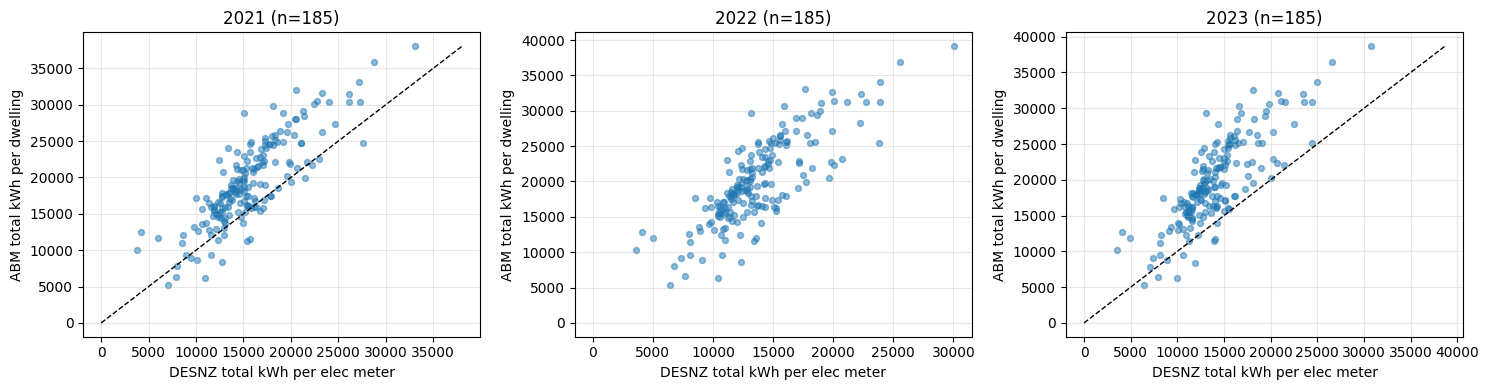

<Figure size 800x400 with 0 Axes>

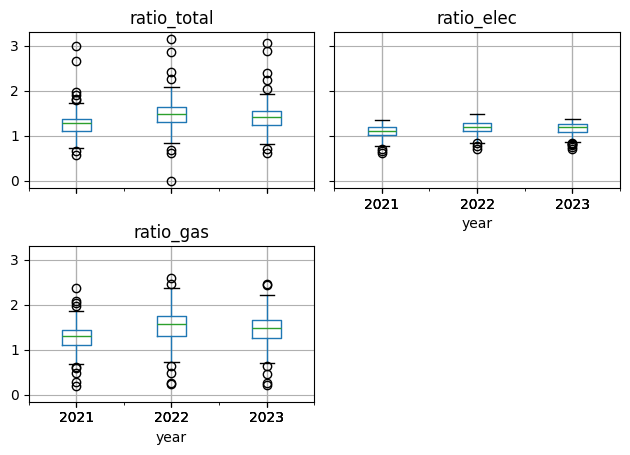

In [34]:
years_sorted = sorted(cmp['year'].unique())
fig, axes = plt.subplots(1, len(years_sorted), figsize=(5*len(years_sorted),4), sharex=False, sharey=False)
if len(years_sorted)==1:
    axes=[axes]
for ax, yr in zip(axes, years_sorted):
    sub = cmp[cmp['year']==yr]
    ax.scatter(sub['desnz_kwh_per_dw'], sub['abm_kwh_per_dw'], alpha=0.5, s=18)
    mx = max(sub['desnz_kwh_per_dw'].max(), sub['abm_kwh_per_dw'].max())
    ax.plot([0,mx],[0,mx],'k--',lw=1)
    ax.set_title(f"{yr} (n={len(sub)})")
    ax.set_xlabel('DESNZ total kWh per elec meter')
    ax.set_ylabel('ABM total kWh per dwelling')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
cmp.boxplot(column=['ratio_total','ratio_elec','ratio_gas'], by='year')
plt.axhline(1.0, color='k', linestyle='--', lw=1)
plt.ylabel('ABM / DESNZ ratio')
plt.title('ABM vs DESNZ ratio by year (total, elec, gas)')
plt.suptitle(''); plt.tight_layout(); plt.show()


## Coverage-aware confidence layer

DESNZ LSOA electricity is an **independent benchmark with known coverage contamination** — it counts meters (empties, second meters, non-EPC stock) that the SERL-calibrated model was never meant to describe. We therefore treat it as a cross-check, **not a calibration target**, and instead quantify *where* the model is trustworthy.

On a like-for-like **total-energy-per-LSOA** basis, EPC-to-meter coverage explains ~75% of the model/DESNZ gap (~80% with electric-heated share added). The cell below builds a per-LSOA confidence tier — coverage weighted 2x (it dominates), plus electric-heated share (SERL sample thinness) and meter count (small-LSOA noise) — and writes `research/applied/lsoa_confidence_2023.csv`, which backs `research/applied/lsoa_confidence_2023.html`.

In [ ]:
# Coverage-aware confidence layer (model vs DESNZ, 2023)
conf = cmp[cmp['year'] == 2023].copy()
if 'abm_elec_kwh' not in conf.columns:
    conf['abm_elec_kwh'] = conf['abm_elec_kwh_per_dw'] * conf['run_dwellings']

# Per-LSOA covariates
conf['coverage']        = conf['run_dwellings'] / conf['elec_meters']             # EPC dwellings / DESNZ meters
conf['elec_heat_share'] = conf['run_electric_heated_dwellings'] / conf['run_dwellings']
conf['tot_ratio']       = conf['abm_elec_kwh'] / conf['elec_kwh']                 # model total / DESNZ total elec

# How much of the per-LSOA gap is mechanical coverage?
def _r2(y, *xs):
    X = np.column_stack([np.ones(len(y))] + list(xs))
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1.0 - (resid**2).sum() / ((y - y.mean())**2).sum()

_v = conf[['tot_ratio', 'coverage', 'elec_heat_share']].replace([np.inf, -np.inf], np.nan).dropna()
print(f"R2(tot_ratio ~ coverage)              = {_r2(_v['tot_ratio'].values, _v['coverage'].values):.3f}")
print(f"R2(tot_ratio ~ coverage + elec share) = {_r2(_v['tot_ratio'].values, _v['coverage'].values, _v['elec_heat_share'].values):.3f}")
print(f"corr(model_total, DESNZ_total)        = {conf['abm_elec_kwh'].corr(conf['elec_kwh']):.3f}")

# Tier rule: coverage weighted 2x + electric-sample thinness + small-LSOA noise; score 0..8
cov_pts  = np.select([conf['coverage'] >= 0.80, conf['coverage'] >= 0.60], [2, 1], 0)
elec_pts = np.select([conf['elec_heat_share'] < 0.20, conf['elec_heat_share'] < 0.40], [2, 1], 0)
size_pts = np.select([conf['elec_meters'] >= 500, conf['elec_meters'] >= 300], [2, 1], 0)
conf['confidence_score'] = 2 * cov_pts + elec_pts + size_pts
conf['confidence'] = np.select(
    [conf['confidence_score'] >= 6, conf['confidence_score'] >= 4], ['High', 'Medium'], 'Low')

# Validate: does the flag separate trustworthy from untrustworthy LSOAs?
tier_summary = conf.groupby('confidence').agg(
    n_lsoa=('tot_ratio', 'size'),
    mean_model_over_desnz=('tot_ratio', 'mean'),
).reindex(['High', 'Medium', 'Low'])
tier_summary['corr_total'] = [conf.loc[conf['confidence'] == t, 'abm_elec_kwh']
                              .corr(conf.loc[conf['confidence'] == t, 'elec_kwh'])
                              for t in tier_summary.index]
print('\nConfidence tiers (model vs DESNZ total energy):')
display(tier_summary.round(3))

# Scatter: coverage explains the LSOA-total gap
_col = {'High': '#059669', 'Medium': '#d97706', 'Low': '#dc2626'}
plt.figure(figsize=(7, 5))
for t in ['High', 'Medium', 'Low']:
    d = conf[conf['confidence'] == t]
    plt.scatter(d['coverage'], d['tot_ratio'], s=np.sqrt(d['elec_meters']) * 2.5,
                c=_col[t], alpha=0.6, edgecolors=_col[t], linewidths=0.5, label=f'{t} (n={len(d)})')
plt.axhline(1.0, color='#9ca3af', ls=':', lw=1)
plt.plot([0, 1.3], [0, 1.3], color='#bbb', ls='--', lw=1, label='ratio = coverage')
plt.xlabel('EPC-to-meter coverage'); plt.ylabel('model total / DESNZ total elec')
plt.title('Per-LSOA confidence vs coverage (2023)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Export the per-LSOA confidence table backing lsoa_confidence_2023.html
_out_cols = [LSOA_COL, 'elec_meters', 'run_dwellings', 'coverage', 'elec_heat_share',
             'abm_elec_kwh', 'elec_kwh', 'tot_ratio', 'confidence_score', 'confidence']
# Canonical CSV (lon/lat/why for the map) is written by the HTML-builder script;
# notebook writes a verification copy so re-running can't clobber it.
_conf_path = Path('../research/applied/lsoa_confidence_2023_notebook.csv')
conf.sort_values(['confidence', 'coverage'])[_out_cols].to_csv(_conf_path, index=False)
print(f'\nWrote {_conf_path}  ({len(conf)} LSOAs)')

## Post-hoc gas miss diagnostics (no rerun)

Identify which LSOA features explain residual gas mismatch using existing `cmp` outputs.


Diagnostic model (Ridge, GroupKFold by LSOA): MAE=4.375 residual-ratio points, R2=-0.527

Top drivers of gas residual (ratio_gas_strict - 1):


,feature,coef
10,num__unknown_share,10.3092
15,cat__gas_denominator_quality_low-uncertainty,5.6814
14,cat__gas_denominator_quality_high-uncertainty,-5.6814
0,num__desnz_kwh_per_dw,2.6887
1,num__elec_kwh_per_dw,-2.2505
6,num__run_off_gas_dwellings,1.9275
4,num__run_gas_dwellings,-1.1428
5,num__run_gas_dwellings_strict,-1.0935
8,num__abm_elec_kwh_per_dw,-0.6944
11,cat__year_2021,-0.6049



LSOAs with largest persistent gas residual miss (strict denominator):


,lsoa_code,n,mean_resid,mean_pred,mean_abs_resid
162,E01008581,3,128.9017,8.8752,128.9017
173,E01035614,3,64.7493,-23.6855,64.7493
174,E01035615,3,16.4272,38.6929,16.4272
175,E01035616,3,13.0706,35.9496,13.0706
163,E01027449,3,9.5388,87.2983,9.5388
158,E01008458,3,5.3647,25.5198,5.3647
18,E01008307,3,4.1782,10.1792,4.1782
17,E01008306,3,3.0175,9.5332,3.0175
149,E01008448,3,2.6789,17.6030,2.6789
10,E01008298,3,2.3591,8.9447,2.3591


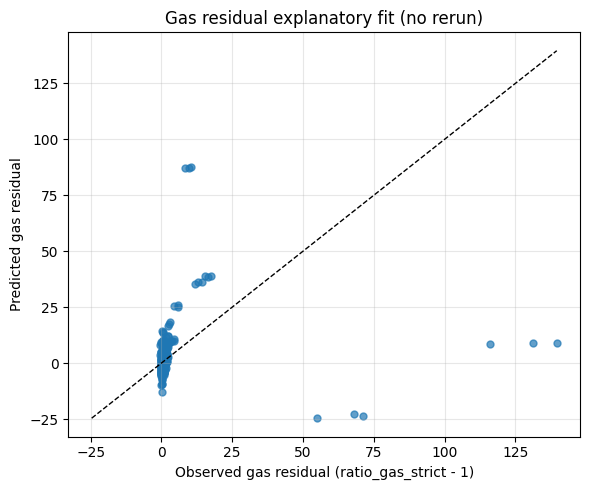

In [35]:
# Post-hoc diagnostics: what drives gas residual miss?
# Uses existing `cmp` table from the prior section; no model rerun required.

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

if 'cmp' not in globals():
    raise RuntimeError('cmp not found. Run the merge/summary cell first.')

# Build one row per LSOA-year with residual target.
diag = cmp.copy()
diag = diag.replace([np.inf, -np.inf], np.nan)
diag['gas_residual_strict'] = diag['ratio_gas_strict'] - 1.0

# Candidate features available from ABM + DESNZ merge
num_features = [
    'desnz_kwh_per_dw',
    'elec_kwh_per_dw',
    'gas_kwh_per_gas_dw',
    'run_dwellings',
    'run_gas_dwellings',
    'run_gas_dwellings_strict',
    'run_off_gas_dwellings',
    'run_unknown_gas_connection_dwellings',
    'abm_elec_kwh_per_dw',
    'abm_gas_kwh_per_dw',
    'unknown_share',
]
cat_features = ['year', 'gas_denominator_quality']

# Keep only columns present in this run
num_features = [c for c in num_features if c in diag.columns]
cat_features = [c for c in cat_features if c in diag.columns]

if not num_features:
    raise RuntimeError('No numeric diagnostic features available in cmp.')

use_cols = ['lsoa_code', 'gas_residual_strict'] + num_features + cat_features
work = diag[use_cols].dropna(subset=['gas_residual_strict', 'lsoa_code']).copy()

X = work[num_features + cat_features]
y = work['gas_residual_strict']
groups = work['lsoa_code'].astype(str)

pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_features),
    ],
    remainder='drop',
)

model = Pipeline([
    ('pre', pre),
    ('reg', Ridge(alpha=1.0, random_state=42)),
])

# Grouped CV by LSOA to avoid leakage across years of same area
n_groups = groups.nunique()
n_splits = min(5, max(2, n_groups))
cv = GroupKFold(n_splits=n_splits)

pred = pd.Series(index=work.index, dtype=float)
for tr, te in cv.split(X, y, groups=groups):
    model.fit(X.iloc[tr], y.iloc[tr])
    pred.iloc[te] = model.predict(X.iloc[te])

mae = mean_absolute_error(y, pred)
r2 = r2_score(y, pred)
print(f'Diagnostic model (Ridge, GroupKFold by LSOA): MAE={mae:.3f} residual-ratio points, R2={r2:.3f}')

# Fit once on all rows for coefficient inspection
model.fit(X, y)

pre_fit = model.named_steps['pre']
reg = model.named_steps['reg']
feature_names = pre_fit.get_feature_names_out()
coefs = pd.DataFrame({'feature': feature_names, 'coef': reg.coef_})
coefs['abs_coef'] = coefs['coef'].abs()
coefs = coefs.sort_values('abs_coef', ascending=False)

print() 
print('Top drivers of gas residual (ratio_gas_strict - 1):')
display(coefs[['feature', 'coef']].head(20).round(4))

# Residual map by LSOA (mean across years)
ls_res = (
    work.assign(pred=pred, resid_obs=y)
        .groupby('lsoa_code', as_index=False)
        .agg(
            n=('resid_obs', 'size'),
            mean_resid=('resid_obs', 'mean'),
            mean_pred=('pred', 'mean'),
            mean_abs_resid=('resid_obs', lambda s: np.mean(np.abs(s))),
        )
        .sort_values('mean_abs_resid', ascending=False)
)

print()
print('LSOAs with largest persistent gas residual miss (strict denominator):')
display(ls_res.head(20).round(4))

# Quick visual check
plt.figure(figsize=(6, 5))
plt.scatter(y, pred, alpha=0.7, s=25)
lo = float(min(y.min(), pred.min()))
hi = float(max(y.max(), pred.max()))
plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
plt.xlabel('Observed gas residual (ratio_gas_strict - 1)')
plt.ylabel('Predicted gas residual')
plt.title('Gas residual explanatory fit (no rerun)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Decision overlays (strict-first KPIs + outlier gating)

Use persistent outlier flags to separate structural signal from denominator/noise effects.


In [36]:
# 1) Outlier-gated headline metrics
if 'cmp' not in globals():
    raise RuntimeError('cmp not found. Run the merge/summary cell first.')
if 'ls_res' not in globals():
    raise RuntimeError('ls_res not found. Run the post-hoc gas diagnostics cell first.')


def _mape(series):
    s = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return float((s.sub(1.0).abs().mean() * 100.0)) if len(s) else np.nan


# Define persistent outlier sets by mean_abs_resid rank
TOP_K_LIST = [5, 10]
outlier_sets = {
    k: set(ls_res.sort_values('mean_abs_resid', ascending=False).head(k)['lsoa_code'].astype(str))
    for k in TOP_K_LIST
}
outlier_sets[0] = set()

rows = []
for k in [0] + TOP_K_LIST:
    flagged = outlier_sets[k]
    sub = cmp[~cmp['lsoa_code'].astype(str).isin(flagged)].copy()
    label = 'all_lsoas' if k == 0 else f'excluding_top_{k}_gas_outliers'

    rows.append({
        'scope': label,
        'n_rows': len(sub),
        'n_lsoas': sub['lsoa_code'].nunique(),
        'mape_total_pct': _mape(sub['ratio_total']),
        'mape_elec_pct': _mape(sub['ratio_elec']),
        'mape_gas_strict_pct': _mape(sub['ratio_gas_strict']),
        'median_ratio_total': sub['ratio_total'].median(),
        'median_ratio_elec': sub['ratio_elec'].median(),
        'median_ratio_gas_strict': sub['ratio_gas_strict'].median(),
    })

gated_summary = pd.DataFrame(rows)
display(gated_summary.round(3).style.set_caption('Outlier-gated headline metrics'))

print('Top-10 persistent gas outlier LSOAs:')
print(sorted(outlier_sets[10]))



,scope,n_rows,n_lsoas,mape_total_pct,mape_elec_pct,mape_gas_strict_pct,median_ratio_total,median_ratio_elec,median_ratio_gas_strict
0,all_lsoas,555,185,40.651000,17.443000,191.709000,1.372000,1.164000,1.556000
1,excluding_top_5_gas_outliers,540,180,39.836000,17.557000,66.370000,1.369000,1.167000,1.535000
2,excluding_top_10_gas_outliers,525,175,38.922000,17.617000,58.116000,1.361000,1.170000,1.519000


Top-10 persistent gas outlier LSOAs:
['E01008298', 'E01008306', 'E01008307', 'E01008448', 'E01008458', 'E01008581', 'E01027449', 'E01035614', 'E01035615', 'E01035616']


In [37]:
# 2) Strict-first KPI table (recommended primary scorecard)
if 'cmp' not in globals():
    raise RuntimeError('cmp not found. Run the merge/summary cell first.')


def _mape(series):
    s = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return float((s.sub(1.0).abs().mean() * 100.0)) if len(s) else np.nan


kpi_rows = []
for yr, sub in cmp.groupby('year'):
    kpi_rows.append({
        'year': int(yr),
        'primary_mape_total_pct': _mape(sub['ratio_total']),
        'primary_mape_elec_pct': _mape(sub['ratio_elec']),
        'primary_mape_gas_strict_pct': _mape(sub['ratio_gas_strict']),
        'sensitivity_mape_gas_assumed_pct': _mape(sub['ratio_gas_assumed']),
        'median_ratio_total': sub['ratio_total'].median(),
        'median_ratio_elec': sub['ratio_elec'].median(),
        'median_ratio_gas_strict': sub['ratio_gas_strict'].median(),
        'median_ratio_gas_assumed': sub['ratio_gas_assumed'].median(),
    })

kpi = pd.DataFrame(kpi_rows).sort_values('year')
display(kpi.round(3).style.set_caption('Strict-first KPI scorecard (primary vs sensitivity)'))



,year,primary_mape_total_pct,primary_mape_elec_pct,primary_mape_gas_strict_pct,sensitivity_mape_gas_assumed_pct,median_ratio_total,median_ratio_elec,median_ratio_gas_strict,median_ratio_gas_assumed
0,2021,28.942000,13.971000,161.897000,33.107000,1.278000,1.116000,1.391000,1.297000
1,2022,49.443000,20.089000,212.614000,56.424000,1.493000,1.202000,1.684000,1.576000
2,2023,43.569000,18.283000,200.615000,49.731000,1.419000,1.188000,1.608000,1.488000


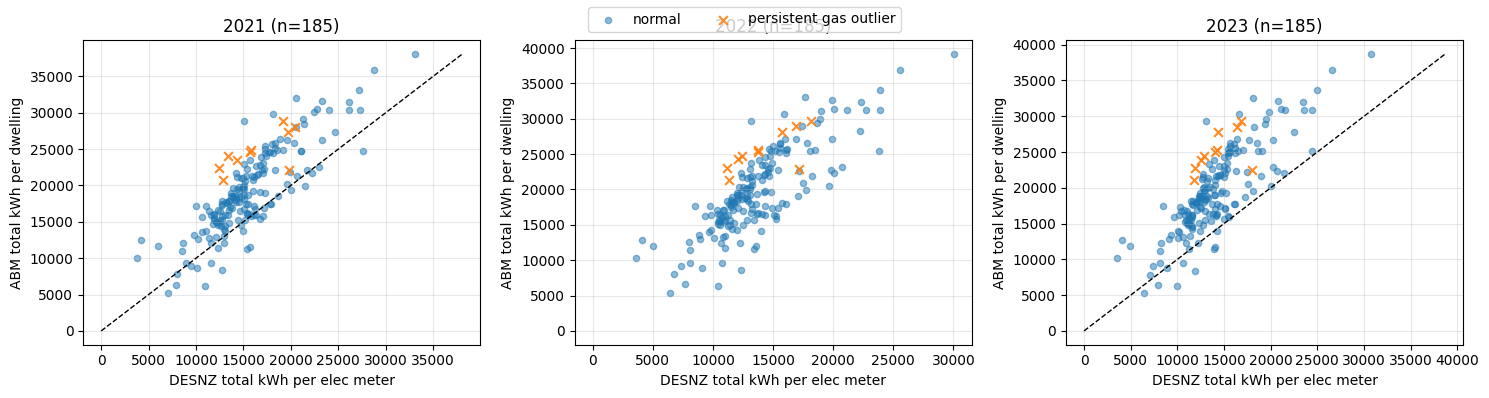

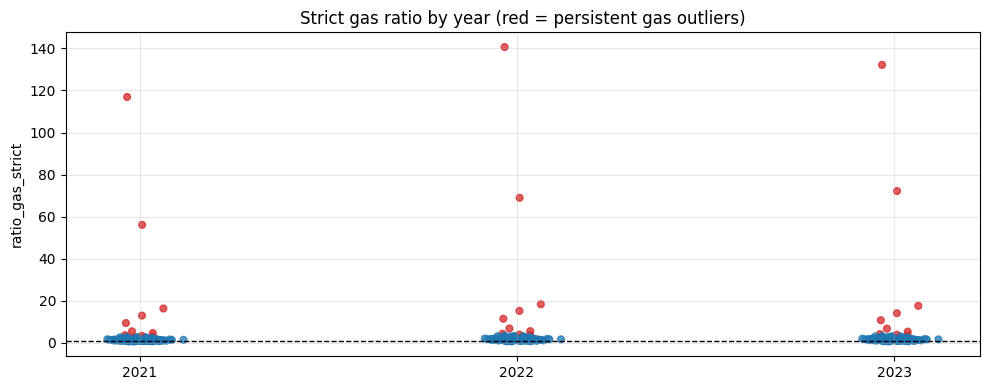

In [38]:
# 3) Overlay plots highlighting persistent gas outliers
if 'cmp' not in globals() or 'ls_res' not in globals():
    raise RuntimeError('Need both cmp and ls_res in memory.')

outlier_lsoas = set(ls_res.sort_values('mean_abs_resid', ascending=False).head(10)['lsoa_code'].astype(str))
plot_df = cmp.copy()
plot_df['is_persistent_outlier'] = plot_df['lsoa_code'].astype(str).isin(outlier_lsoas)

years_sorted = sorted(plot_df['year'].dropna().unique())
fig, axes = plt.subplots(1, len(years_sorted), figsize=(5 * len(years_sorted), 4), sharex=False, sharey=False)
if len(years_sorted) == 1:
    axes = [axes]

for ax, yr in zip(axes, years_sorted):
    sub = plot_df[plot_df['year'] == yr]
    normal = sub[~sub['is_persistent_outlier']]
    out = sub[sub['is_persistent_outlier']]

    ax.scatter(normal['desnz_kwh_per_dw'], normal['abm_kwh_per_dw'], alpha=0.5, s=20, label='normal')
    ax.scatter(out['desnz_kwh_per_dw'], out['abm_kwh_per_dw'], alpha=0.9, s=40, marker='x', label='persistent gas outlier')

    mx = max(sub['desnz_kwh_per_dw'].max(), sub['abm_kwh_per_dw'].max())
    ax.plot([0, mx], [0, mx], 'k--', lw=1)
    ax.set_title(f'{yr} (n={len(sub)})')
    ax.set_xlabel('DESNZ total kWh per elec meter')
    ax.set_ylabel('ABM total kWh per dwelling')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

# Ratio strip for strict gas ratio
plt.figure(figsize=(10, 4))
for i, yr in enumerate(years_sorted, start=1):
    sub = plot_df[plot_df['year'] == yr]
    x = np.full(len(sub), i, dtype=float)
    jitter = np.random.default_rng(42).normal(0, 0.04, size=len(sub))
    plt.scatter(x + jitter, sub['ratio_gas_strict'],
                c=np.where(sub['is_persistent_outlier'], '#d62728', '#1f77b4'),
                alpha=0.75, s=24)

plt.axhline(1.0, color='k', linestyle='--', lw=1)
plt.xticks(range(1, len(years_sorted) + 1), [str(y) for y in years_sorted])
plt.ylabel('ratio_gas_strict')
plt.title('Strict gas ratio by year (red = persistent gas outliers)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Release Gate (LSOA reliability + export policy)

Classify unreliable LSOAs, compute gate status, and export full + reliable-only outputs.


In [40]:
# Release gate: flag unreliable LSOAs and export filtered outputs
if 'cmp' not in globals():
    raise RuntimeError('cmp not found. Run the merge/summary cell first.')
if 'ls_res' not in globals():
    raise RuntimeError('ls_res not found. Run the post-hoc gas diagnostics cell first.')

# --- Gate policy knobs ---
UNKNOWN_SHARE_GATE = 0.07            # mark high gas-connection uncertainty
PERSISTENT_OUTLIER_TOP_K = 10         # top-K by mean_abs_resid from ls_res
STRICT_GAS_MAPE_PASS = 20.0           # pass threshold (%) on reliable subset
TOTAL_MAPE_PASS = 18.0                # pass threshold (%) on reliable subset
STRICT_GAS_MAPE_WARN = 24.0           # warn threshold (%)
TOTAL_MAPE_WARN = 22.0                # warn threshold (%)

# Optional policy switch for downstream consumers
EXPORT_RELIABLE_ONLY = False


def _mape(series):
    s = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return float((s.sub(1.0).abs().mean() * 100.0)) if len(s) else np.nan


# LSOA-level reliability flags
outlier_lsoas = set(
    ls_res.sort_values('mean_abs_resid', ascending=False)
         .head(PERSISTENT_OUTLIER_TOP_K)['lsoa_code'].astype(str)
)

lsoa_flags = (
    cmp.groupby('lsoa_code', as_index=False)
       .agg(
           max_unknown_share=('unknown_share', 'max'),
           median_ratio_gas_strict=('ratio_gas_strict', 'median'),
           median_ratio_total=('ratio_total', 'median'),
       )
)
lsoa_flags['is_high_unknown'] = lsoa_flags['max_unknown_share'] > UNKNOWN_SHARE_GATE
lsoa_flags['is_persistent_outlier'] = lsoa_flags['lsoa_code'].astype(str).isin(outlier_lsoas)
lsoa_flags['is_reliable_lsoa'] = ~(lsoa_flags['is_high_unknown'] | lsoa_flags['is_persistent_outlier'])

# Join back to row-level table
cmp_gate = cmp.merge(
    lsoa_flags[['lsoa_code', 'is_high_unknown', 'is_persistent_outlier', 'is_reliable_lsoa']],
    on='lsoa_code',
    how='left',
)

reliable = cmp_gate[cmp_gate['is_reliable_lsoa']].copy()

# Gate metrics
gate_metrics = {
    'all_rows': len(cmp_gate),
    'all_lsoas': int(cmp_gate['lsoa_code'].nunique()),
    'reliable_rows': len(reliable),
    'reliable_lsoas': int(reliable['lsoa_code'].nunique()),
    'excluded_lsoas': int((~lsoa_flags['is_reliable_lsoa']).sum()),
    'mape_total_all_pct': _mape(cmp_gate['ratio_total']),
    'mape_gas_strict_all_pct': _mape(cmp_gate['ratio_gas_strict']),
    'mape_total_reliable_pct': _mape(reliable['ratio_total']),
    'mape_gas_strict_reliable_pct': _mape(reliable['ratio_gas_strict']),
}

# Pass/Warn/Fail logic based on reliable subset
mt = gate_metrics['mape_total_reliable_pct']
mg = gate_metrics['mape_gas_strict_reliable_pct']
if (mt <= TOTAL_MAPE_PASS) and (mg <= STRICT_GAS_MAPE_PASS):
    gate_status = 'PASS'
elif (mt <= TOTAL_MAPE_WARN) and (mg <= STRICT_GAS_MAPE_WARN):
    gate_status = 'WARN'
else:
    gate_status = 'FAIL'

# Report
gate_df = pd.DataFrame([gate_metrics])
gate_df.insert(0, 'gate_status', gate_status)
display(gate_df.round(3).style.set_caption('Release gate summary'))

print()
print('Excluded LSOAs (unreliable by gate):')
print(sorted(lsoa_flags.loc[~lsoa_flags['is_reliable_lsoa'], 'lsoa_code'].astype(str).tolist()))

# Exports
OUT_GATE = Path('results/calibration')
OUT_GATE.mkdir(parents=True, exist_ok=True)
stamp = pd.Timestamp.utcnow().strftime('%Y%m%d_%H%M%S')

full_path = OUT_GATE / f'cmp_with_reliability_{stamp}.csv'
reliable_path = OUT_GATE / f'cmp_reliable_only_{stamp}.csv'
summary_path = OUT_GATE / f'release_gate_summary_{stamp}.csv'

cmp_gate.to_csv(full_path, index=False)
reliable.to_csv(reliable_path, index=False)
gate_df.to_csv(summary_path, index=False)

print(f'Wrote full tagged output:      {full_path}')
print(f'Wrote reliable-only output:    {reliable_path}')
print(f'Wrote release gate summary:    {summary_path}')

publish_df = reliable if EXPORT_RELIABLE_ONLY else cmp_gate
mode = 'reliable-only' if EXPORT_RELIABLE_ONLY else 'full-with-flags'
print(f'Publish mode: {mode}; rows={len(publish_df):,}')



,gate_status,all_rows,all_lsoas,reliable_rows,reliable_lsoas,excluded_lsoas,mape_total_all_pct,mape_gas_strict_all_pct,mape_total_reliable_pct,mape_gas_strict_reliable_pct
0,FAIL,555,185,333,111,74,40.651000,191.709000,36.259000,42.157000



Excluded LSOAs (unreliable by gate):
['E01008289', 'E01008290', 'E01008291', 'E01008295', 'E01008297', 'E01008298', 'E01008299', 'E01008300', 'E01008306', 'E01008307', 'E01008311', 'E01008320', 'E01008323', 'E01008325', 'E01008327', 'E01008329', 'E01008330', 'E01008339', 'E01008340', 'E01008348', 'E01008350', 'E01008351', 'E01008355', 'E01008358', 'E01008370', 'E01008371', 'E01008375', 'E01008379', 'E01008381', 'E01008383', 'E01008389', 'E01008391', 'E01008392', 'E01008400', 'E01008402', 'E01008403', 'E01008405', 'E01008407', 'E01008425', 'E01008426', 'E01008427', 'E01008428', 'E01008429', 'E01008431', 'E01008432', 'E01008433', 'E01008436', 'E01008437', 'E01008439', 'E01008441', 'E01008443', 'E01008444', 'E01008445', 'E01008447', 'E01008448', 'E01008450', 'E01008457', 'E01008458', 'E01008577', 'E01008581', 'E01008582', 'E01027449', 'E01033543', 'E01033545', 'E01033547', 'E01033548', 'E01033551', 'E01033553', 'E01035613', 'E01035614', 'E01035615', 'E01035616', 'E01035617', 'E01035623']